In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate
from scipy.integrate import odeint



def f(t,X):
    x, y, z = X
    
    return np.array([
         10*(y-x),
         28*x - x*z - y,
         x*y - 8*z/3
    ])

In [2]:
X0 = np.array([5,5,5])
EPSILON = 1e-9
X02 = np.array([5,5,5+EPSILON])
N = 10000
t_eval = np.linspace(0, 40, N)
#t_eval = torch.linspace(0.0, 30.0, 3000, device=device)


sol1 = scipy.integrate.solve_ivp(f, (0, 40), X0, t_eval=t_eval, rtol=1e-10, atol=1e-12)
sol2 = scipy.integrate.solve_ivp(f, (0, 40), X02, t_eval=t_eval, rtol=1e-10, atol=1e-12)

print(sol1.y[:,-1])
print(sol2.y[:,-1])

[-2.66774175 -0.24345276 24.79751701]
[ 9.25613523 16.83484664 13.73990251]


<Figure size 640x480 with 0 Axes>

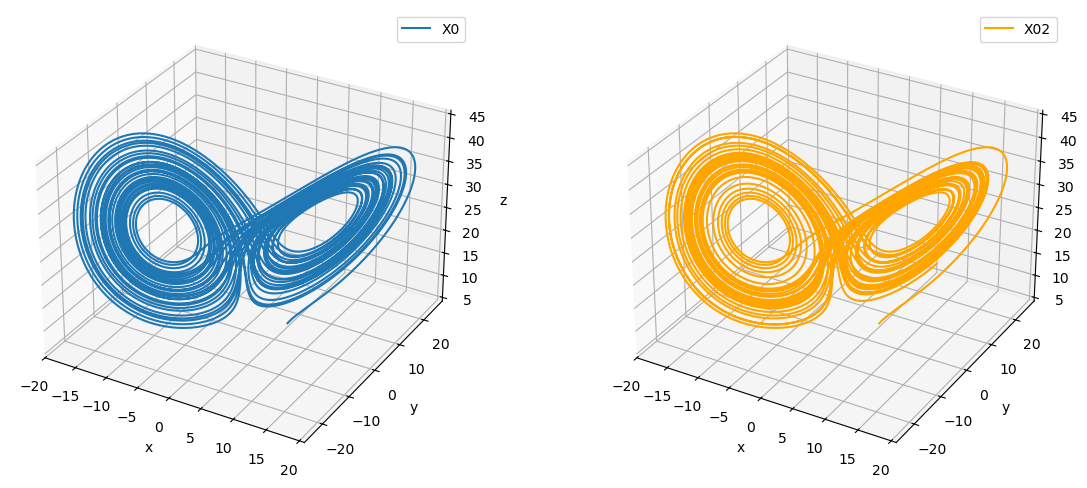

In [3]:
fig = plt.figure()
fig, ax = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={"projection": "3d"})
ax[0].plot(sol1.y[0], sol1.y[1], sol1.y[2], label="X0")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_zlabel("z")
ax[0].legend()
ax[1].plot(sol2.y[0], sol2.y[1], sol2.y[2], color="orange", label="X02")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].set_zlabel("z")
ax[1].legend()
plt.show()


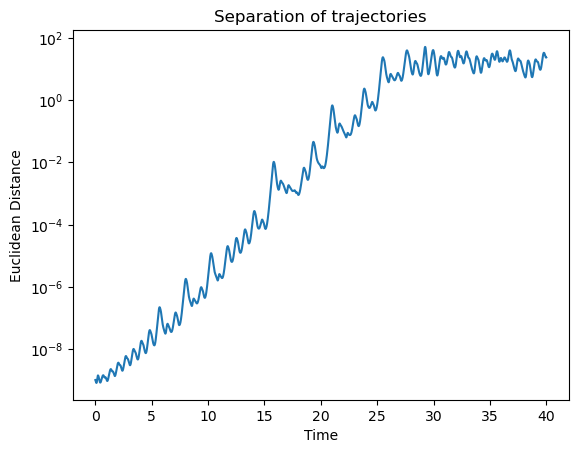

In [4]:
euc_dist = np.sqrt(np.sum((sol1.y - sol2.y)**2, axis=0))
plt.plot(sol1.t, euc_dist)  
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Euclidean Distance")
plt.title("Separation of trajectories")
plt.show()


In [5]:
seed = 42
np.random.seed(seed)
x = np.random.uniform(-15,15, size=100)
y = np.random.uniform(-15,15, size=100)
z = np.random.uniform(0,30, size=100)

X0_base = np.array([x,y,z])
X0_alt = np.zeros_like(X0_base)

for i in range(X0_base.shape[1]):
    random_index = np.random.randint(0, 3)
    epsilon_vector = np.zeros(3)    
    epsilon_vector[random_index] = EPSILON
    X0_alt[:,i] = X0_base[:,i] + epsilon_vector

base_solutions = []
alt_solutions = []
for i in range(X0_base.shape[1]):
    sol_base = scipy.integrate.solve_ivp(f, (0, 40), X0_base[:,i], t_eval=t_eval, rtol=1e-10, atol=1e-12)
    sol_alt = scipy.integrate.solve_ivp(f, (0, 40), X0_alt[:,i], t_eval=t_eval, rtol=1e-10, atol=1e-12)
    base_solutions.append(sol_base)
    alt_solutions.append(sol_alt)
    

Estimated Lyapunov exponent: 0.9153


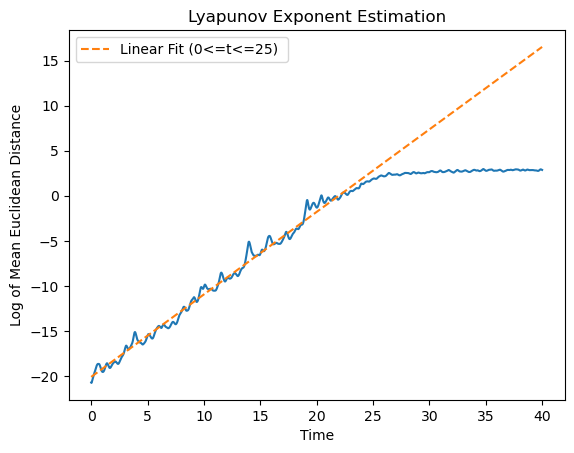

Estimated Lyapunov time: 1.0925


In [6]:
distances = []
for sol_base, sol_alt in zip(base_solutions, alt_solutions):
    dist = np.sqrt(np.sum((sol_base.y - sol_alt.y)**2, axis=0))
    distances.append(dist)
mean_distance = np.mean(distances, axis=0)
log_mean_distance = np.log(mean_distance)
t_region = t_eval[t_eval <= 25]
log_mean_distance_region = log_mean_distance[t_eval <= 25]
model = np.polyfit(t_region, log_mean_distance_region, 1)
print(f"Estimated Lyapunov exponent: {model[0]:.4f}")
fit_line = np.poly1d(model)(t_eval)
plt.plot(t_eval, log_mean_distance)
plt.plot(t_eval, fit_line, '--', label="Linear Fit (0<=t<=25) ")
plt.xlabel("Time")
plt.ylabel("Log of Mean Euclidean Distance")
plt.title("Lyapunov Exponent Estimation")
plt.legend()
plt.show()
lambda_estimate = model[0]
lypunov_time = 1 / lambda_estimate
print(f"Estimated Lyapunov time: {lypunov_time:.4f}")



## TASK 2

In [7]:
seed = 40
np.random.seed(seed)
x = np.random.uniform(-15,15, size=100)
y = np.random.uniform(-15,15, size=100)
z = np.random.uniform(0,30, size=100)
t_eval_mlp = np.linspace(0, 4, 400) # war 4
#t_eval = torch.linspace(0.0, 30.0, 3000, device=device)

X0_base_nn = np.array([x,y,z])

base_solutions_nn = []
for i in range(X0_base_nn.shape[1]):
    sol_base_nn = scipy.integrate.solve_ivp(f, (0, 10), X0_base_nn[:,i], t_eval=t_eval_mlp, rtol=1e-10, atol=1e-12)
    base_solutions_nn.append(sol_base_nn)
    

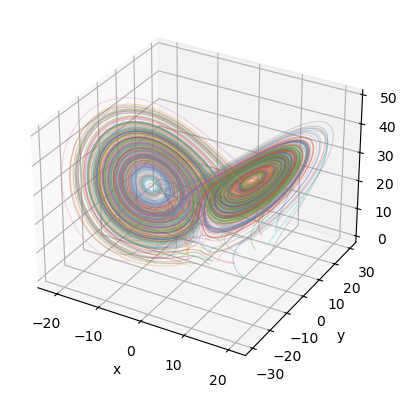

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for sol in base_solutions_nn[0:100]:
    ax.plot(sol.y[0], sol.y[1], sol.y[2], alpha=0.3, linewidth=0.8)
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_xlabel("x")
plt.show()

train_solutions = base_solutions_nn[:80]
test_solutions = base_solutions_nn[80:]

In [9]:
inputs = np.array([sol.y.T[ :-1,:] for sol in train_solutions])
labels = np.array([sol.y.T[ 1:,:] for sol in train_solutions])

inputs_test = np.array([sol.y.T[ :-1,:] for sol in test_solutions])
labels_test = np.array([sol.y.T[ 1:,:] for sol in test_solutions])



input_reshaped = inputs.reshape(-1, 3)
labels_reshaped = labels.reshape(-1, 3)
input_test_reshaped = inputs_test.reshape(-1, 3)
labels_test_reshaped = labels_test.reshape(-1, 3)
input_reshaped.shape, labels_reshaped.shape, input_test_reshaped.shape, labels_test_reshaped.shape

((31920, 3), (31920, 3), (7980, 3), (7980, 3))

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

data_min =  np.min(labels_test_reshaped)
data_max = np.max(labels_test_reshaped)

input_scaled = scaler.fit_transform(input_reshaped)
labels_scaled = scaler.transform(labels_reshaped)
inputs_test_scaled = scaler.transform(input_test_reshaped)
labels_test_scaled = scaler.transform(labels_test_reshaped)


In [11]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# The training data come from scipy, and the network is a plain MLP (no torchdiffeq), so the
# MPS backend works fine here.
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
np.random.seed(7)
torch.manual_seed(7)
print("Using device:", device)

Using device: mps


In [12]:
class History:
    def __init__(self):
        self.history = {"loss": [], "val_loss": []}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class FeedForwardNN(nn.Module):
    """One-step predictor: maps x(t_k) -> x(t_{k+1})."""
    def __init__(self, dim=1, hidden=20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim),   # no activation after the output
        )

    def forward(self, x):
        return self.net(x)


model_mlp = FeedForwardNN(dim=3, hidden=20).to(device)
model_mlp = model_mlp.to(device)
print(model_mlp)
print(f"Trainable params: {count_parameters(model_mlp):,}")

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)

FeedForwardNN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)
Trainable params: 563


In [13]:
def make_loader(X, y, batch_size=256, shuffle=True):
    X_tensor = torch.as_tensor(X, dtype=torch.float32)
    y_tensor = torch.as_tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, optimizer, loss_fn, epochs, val_loader=None):
    hist = History()
    for epoch in range(epochs):
        model.train()
        train_loss, train_count = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.shape[0]
            train_count += xb.shape[0]
        train_loss /= train_count
        hist.history["loss"].append(train_loss)
        message = f"Epoch {epoch + 1}/{epochs} - loss: {train_loss:.6g}"

        if val_loader is not None:
            model.eval()
            val_loss, val_count = 0.0, 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += loss_fn(model(xb), yb).item() * xb.shape[0]
                    val_count += xb.shape[0]
            val_loss /= val_count
            hist.history["val_loss"].append(val_loss)
            message += f" - val_loss: {val_loss:.6g}"

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(message)
    return hist


train_loader = make_loader(input_scaled, labels_scaled, batch_size=256, shuffle=True)
val_loader = make_loader(inputs_test_scaled, labels_test_scaled, batch_size=256, shuffle=False)
hist = train_model(model_mlp, train_loader, optimizer, loss_fn, epochs=200, val_loader=val_loader)

Epoch 1/200 - loss: 0.0493378 - val_loss: 0.00437239
Epoch 10/200 - loss: 0.000110993 - val_loss: 0.000115517
Epoch 20/200 - loss: 5.87354e-05 - val_loss: 6.11885e-05
Epoch 30/200 - loss: 2.2237e-05 - val_loss: 2.11734e-05
Epoch 40/200 - loss: 9.1012e-06 - val_loss: 9.27508e-06
Epoch 50/200 - loss: 6.16863e-06 - val_loss: 6.1441e-06
Epoch 60/200 - loss: 5.19815e-06 - val_loss: 5.3113e-06
Epoch 70/200 - loss: 4.38457e-06 - val_loss: 4.85504e-06
Epoch 80/200 - loss: 3.28632e-06 - val_loss: 2.76392e-06
Epoch 90/200 - loss: 2.74897e-06 - val_loss: 3.52447e-06
Epoch 100/200 - loss: 2.67199e-06 - val_loss: 2.97304e-06
Epoch 110/200 - loss: 2.31814e-06 - val_loss: 2.46356e-06
Epoch 120/200 - loss: 2.02951e-06 - val_loss: 1.84821e-06
Epoch 130/200 - loss: 1.72526e-06 - val_loss: 3.13107e-06
Epoch 140/200 - loss: 1.97389e-06 - val_loss: 1.23257e-06
Epoch 150/200 - loss: 1.65408e-06 - val_loss: 3.83686e-06
Epoch 160/200 - loss: 1.76069e-06 - val_loss: 2.13119e-06
Epoch 170/200 - loss: 1.31652e-0

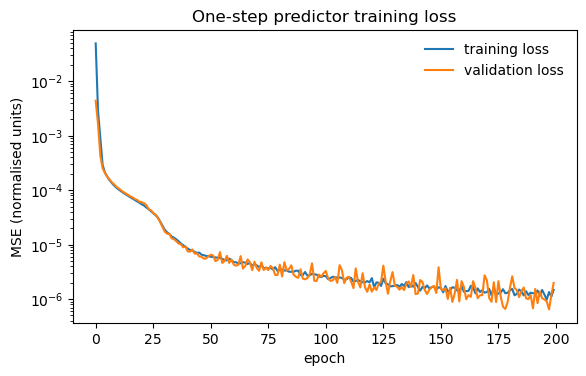

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogy(hist.history["loss"], label="training loss")
ax.semilogy(hist.history["val_loss"], label="validation loss")
ax.legend(frameon=False)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE (normalised units)")
ax.set_title("One-step predictor training loss")
plt.savefig("vallosmlp.png")
plt.show()

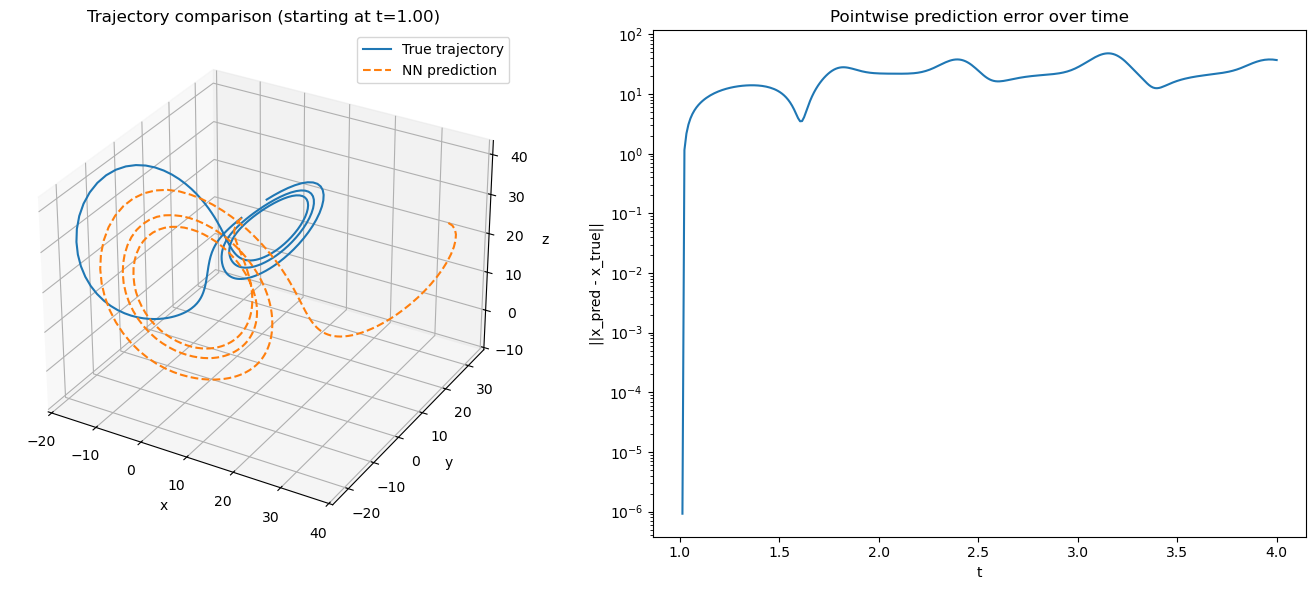

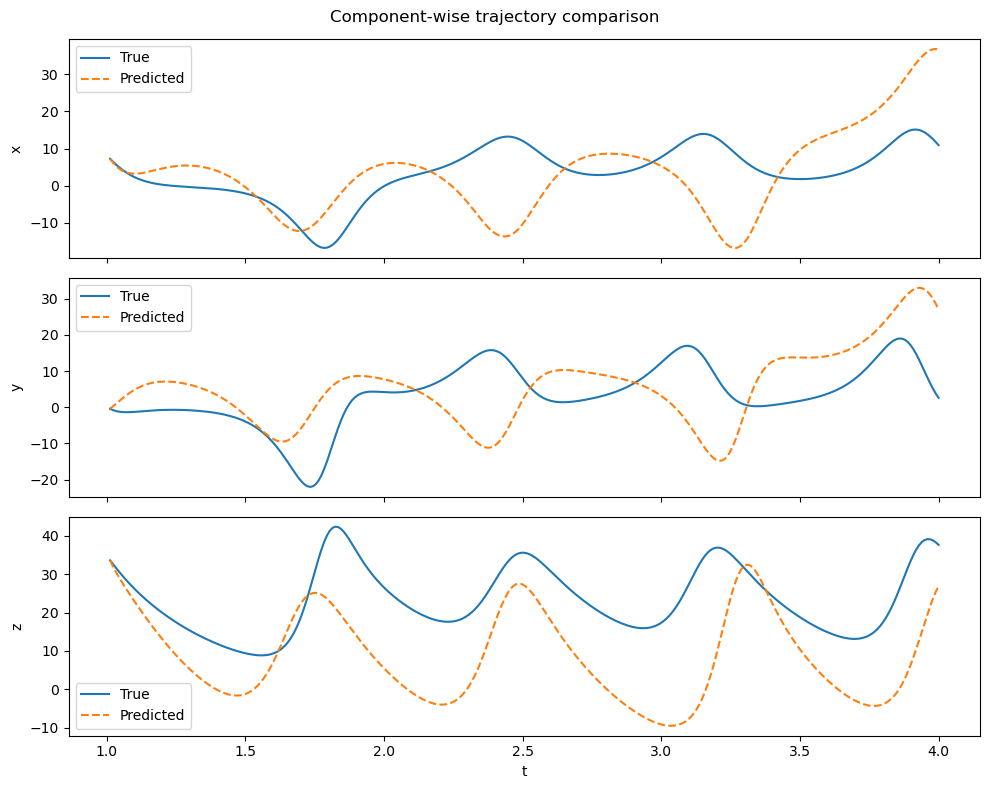

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# rollout function
def predict_trajectory(model, x0_scaled, n_steps, scaler_min, scaler_max, data_min, data_max):
    """
    x0_scaled: normalized initial condition, shape (3,)
    Returns predicted trajectory in normalized space, shape (n_steps+1, 3)
    """
    model.eval()
    traj = np.zeros((n_steps + 1, 3), dtype=np.float32)
    traj[0] = x0_scaled
    x = torch.as_tensor(x0_scaled, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        for k in range(n_steps):
            x = model(x)
            traj[k + 1] = x.cpu().numpy()[0]
    return traj


def normalize(x, data_min, data_max):
    return 2 * (x - data_min) / (data_max - data_min) - 1


def denormalize(x_scaled, data_min, data_max):
    return (x_scaled + 1) / 2 * (data_max - data_min) + data_min


# --- pick a test trajectory ---
# Assume X_test_traj has shape (N_test, Nt, 3) - the UNREASHAPED, UNSCALED test trajectories
# and t_eval is the array of Nt time points (0...4)
# and data_min, data_max are the global min/max used for normalization (shape (3,) or scalars)

X_test_traj = inputs_test


traj_idx = 13  # pick a test trajectory
true_traj = X_test_traj[traj_idx]  # shape (Nt, 3), unscaled

# Start the comparison at t = 1 instead of t = 0, as suggested
t_start_idx = np.argmin(np.abs(t_eval_mlp - 1.0))
#n_steps = len(t_eval) - 1 - t_start_idx
n_steps = len(true_traj) - 1 - t_start_idx

x0 = true_traj[t_start_idx]  # true position at t=1
x0_scaled = normalize(x0, data_min, data_max).astype(np.float32)



# rollout
pred_traj_scaled = predict_trajectory(model_mlp, x0_scaled, n_steps, None, None, data_min, data_max)
pred_traj = denormalize(pred_traj_scaled, data_min, data_max)

true_traj_from_t1 = true_traj[t_start_idx:]

# --- 3D plot ---
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(true_traj_from_t1[:, 0], true_traj_from_t1[:, 1], true_traj_from_t1[:, 2],
         label='True trajectory', color='C0')
ax1.plot(pred_traj[:, 0], pred_traj[:, 1], pred_traj[:, 2],
         label='NN prediction', color='C1', linestyle='--')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.set_title(f'Trajectory comparison (starting at t={t_eval_mlp[t_start_idx]:.2f})')
ax1.legend()

# --- pointwise error over time ---
ax2 = fig.add_subplot(122)
time_axis = t_eval_mlp[t_start_idx+1:]
error = np.linalg.norm(pred_traj - true_traj_from_t1, axis=1)
ax2.plot(time_axis, error)
ax2.set_xlabel('t')
ax2.set_ylabel('||x_pred - x_true||')
ax2.set_title('Pointwise prediction error over time')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig("plot1.png")
plt.show()

# --- per-component comparison ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = ['x', 'y', 'z']
for i, ax in enumerate(axes):
    ax.plot(time_axis, true_traj_from_t1[:, i], label='True', color='C0')
    ax.plot(time_axis, pred_traj[:, i], label='Predicted', color='C1', linestyle='--')
    ax.set_ylabel(labels[i])
    ax.legend()
axes[-1].set_xlabel('t')
plt.suptitle('Component-wise trajectory comparison')
plt.tight_layout()
plt.savefig("plot2.png")
plt.show()

## Neural ODE

In [16]:
import scipy
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
np.random.seed(7)

def as_list(x):
    """Plot tensors without relying on the PyTorch-to-NumPy bridge."""
    return x.detach().cpu().tolist()

print("Using device:", device)

Using device: cpu


In [17]:
class TrueLorenz(nn.Module):
    def __init__(self, sigma=10.0, rho=28.0, beta=8.0/3.0):
        super().__init__()
        self.sigma = sigma
        self.rho = rho
        self.beta = beta

    def forward(self, t, x):
        # x shape: [..., 3]
        x1 = x[..., 0]
        x2 = x[..., 1]
        x3 = x[..., 2]
        dx1 = self.sigma * (x2 - x1)
        dx2 = x1 * (self.rho - x3) - x2
        dx3 = x1 * x2 - self.beta * x3
        return torch.stack([dx1, dx2, dx3], dim=-1)

true_rhs = TrueLorenz().to(device)

In [18]:
N_TRAJ = 30
N_TIME = 100
T = 2.0

t_eval_nn = np.linspace(0.0, T, N_TIME)
t = torch.linspace(0.0, T, N_TIME, device=device)
dt = t[1] - t[0]



np.random.seed(0)
x0_train = np.random.uniform(low=[-15, -15, 10], high=[15, 15, 40], size=(N_TRAJ, 3))

trajs = np.zeros((N_TRAJ, N_TIME, 3))
for i in range(N_TRAJ):
    sol = solve_ivp(f, [0, T], x0_train[i], t_eval=t_eval_nn, method='RK45')
    trajs[i] = sol.y.T

x_obs = torch.as_tensor(trajs, dtype=torch.float32, device=device)



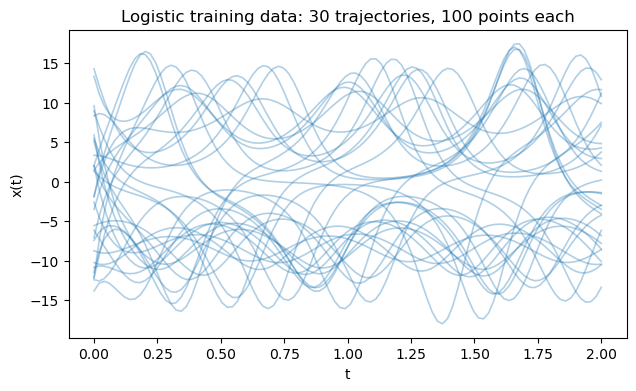

In [19]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for j in range(N_TRAJ):
    ax.plot(as_list(t), as_list(x_obs[j, :, 0]), color="C0", alpha=0.35, lw=1.2)
    #ax.scatter(as_list(t[::8]), as_list(x_obs[j, ::8, 0]), color="k", alpha=0.25, s=8)
ax.set_xlabel("t")
ax.set_ylabel("x(t)")
ax.set_title(f"Logistic training data: {N_TRAJ} trajectories, {N_TIME} points each")
plt.show()

In [20]:
class NeuralLogistic(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3),
        )

        # Normalization buffers make optimization less sensitive to units.
        self.register_buffer("x_mean", torch.zeros(3))
        self.register_buffer("x_std", torch.ones(3))
        self.register_buffer("dxdt_std", torch.ones(3))

    def set_normalization(self, x_mean, x_std, dxdt_std):
        self.x_mean.copy_(x_mean)
        self.x_std.copy_(x_std)
        self.dxdt_std.copy_(dxdt_std)

    def forward(self, t, x):
        x_norm = (x - self.x_mean) / self.x_std
        return self.dxdt_std * self.net(x_norm)

In [21]:
#def estimate_normalization(x_data):
 #   x_flat = x_data.reshape(-1, 1)
  #  x_mean = x_flat.mean(0)
   # x_std = x_flat.std(0).clamp_min(1e-6)

#    dxdt = (x_data[:, 1:] - x_data[:, :-1]) / dt
 #   dxdt_std = dxdt.reshape(-1, 1).std(0).clamp(min=0.2, max=3.0)
  #  return x_mean, x_std, dxdt_std
#def estimate_normalization(x_data):
 #   x_flat = x_data.reshape(-1, 3)
  #  x_mean = x_flat.mean(0)
   # x_std = x_flat.std(0).clamp_min(1e-6)
    #dxdt = (x_data[:, 1:] - x_data[:, :-1]) / dt
    #dxdt_std = dxdt.reshape(-1, 3).std(0).clamp(min=0.2, max=3.0)
    #return x_mean, x_std, dxdt_std

def estimate_normalization(x_data):
    x_flat = x_data.reshape(-1, 3)
    x_mean = x_flat.mean(0)
    x_std = x_flat.std(0).clamp_min(1e-6)
    dxdt = (x_data[:, 1:] - x_data[:, :-1]) / dt
    dxdt_std = dxdt.reshape(-1, 3).std(0).clamp_min(1e-6)  # kein max-clamp!
    return x_mean, x_std, dxdt_std

model_nn = NeuralLogistic(hidden_dim=32).to(device)
model_nn.set_normalization(*estimate_normalization(x_obs))

print(model_nn)

NeuralLogistic(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [22]:
WINDOW_SIZE = 30
BATCH_SIZE = 32

t_window = torch.arange(WINDOW_SIZE, device=device).float() * dt

def sample_window_batch(x_data, batch_size=BATCH_SIZE, window_size=WINDOW_SIZE):
    n_traj, n_time, _ = x_data.shape
    traj_idx = np.random.randint(0, n_traj, size=batch_size)
    starts = np.random.randint(0, n_time - window_size, size=batch_size)

    x0_batch = torch.stack([x_data[j, s] for j, s in zip(traj_idx, starts)])
    y_batch = torch.stack([x_data[j, s:s + window_size] for j, s in zip(traj_idx, starts)])
    return x0_batch, y_batch


x0_batch, y_batch = sample_window_batch(x_obs)
print("x0_batch:", tuple(x0_batch.shape))
print("y_batch:", tuple(y_batch.shape))

x0_batch: (32, 3)
y_batch: (32, 30, 3)


In [23]:
optimizer = optim.Adam(model_nn.parameters(), lr=3e-3)
loss_fn = nn.MSELoss()

N_STEPS = 1000
losses = []

for step in range(1, N_STEPS + 1):
    x0_batch, y_batch = sample_window_batch(x_obs)

    pred = odeint(model_nn, x0_batch, t_window, method="rk4")  # [WINDOW_SIZE, BATCH_SIZE, 1]
    target = y_batch.permute(1, 0, 2)                       # [WINDOW_SIZE, BATCH_SIZE, 1]
    loss = loss_fn(pred, target)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_nn.parameters(), max_norm=10.0)
    optimizer.step()

    if step == 1 or step % 10 == 0:
        losses.append((step, float(loss.detach().cpu())))

    if step % 100 == 0:
        print(f"step {step:4d} | loss {loss.item():.4e}")

step  100 | loss 3.4048e+01
step  200 | loss 3.6380e+01
step  300 | loss 1.1736e+01
step  400 | loss 1.4632e+01
step  500 | loss 6.9106e+00
step  600 | loss 4.6622e+00
step  700 | loss 5.4899e+00
step  800 | loss 6.0991e+00
step  900 | loss 3.7364e+00
step 1000 | loss 5.0597e+00


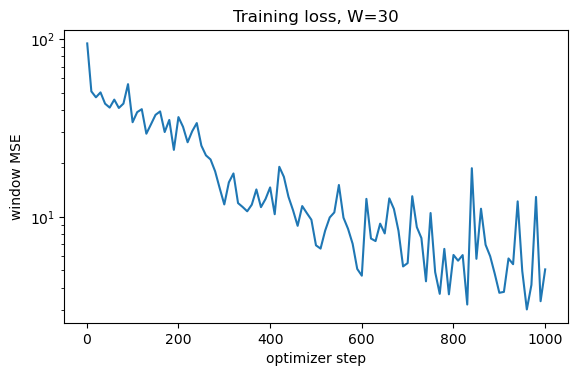

In [24]:
losses = np.array(losses)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(losses[:, 0], losses[:, 1])
ax.set_yscale("log")
ax.set_xlabel("optimizer step")
ax.set_ylabel("window MSE")
ax.set_title(f"Training loss, W={WINDOW_SIZE}")
plt.show()

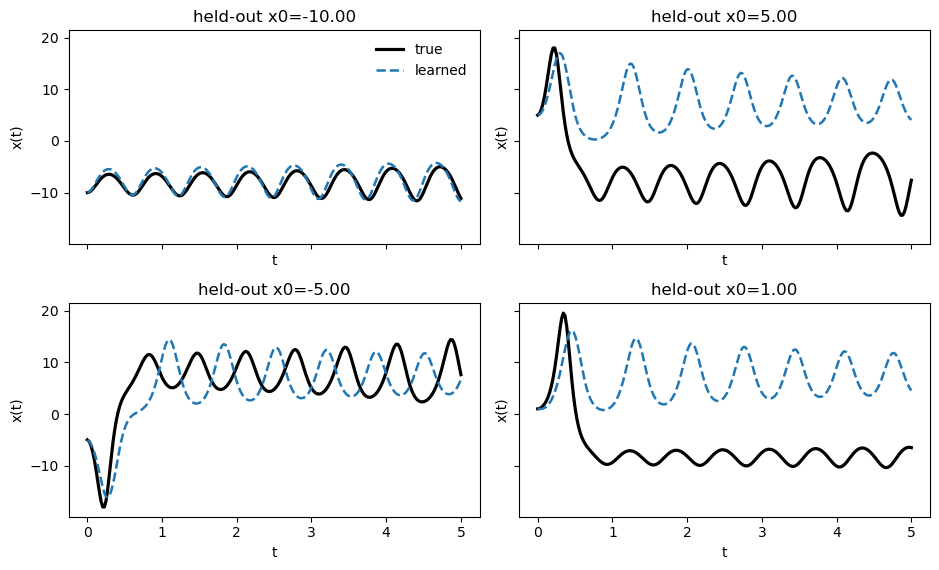

In [25]:
t_eval_nn = torch.linspace(0.0, 5.0, 220, device=device)
#x0_eval = torch.tensor([[0.03], [0.12], [0.42], [0.72]], device=device)
x0_eval = torch.tensor([
    [-10.0, -10.0, 30.0],
    [5.0, 5.0, 5.0],
    [-5.0, -5.0, 5.0],
    [1.0, 1.0, 1.0],    
], device=device)

with torch.no_grad():
    true_eval = odeint(true_rhs, x0_eval, t_eval_nn, method="dopri5").permute(1, 0, 2)

model_nn.eval()

fig, axes = plt.subplots(2, 2, figsize=(9.5, 5.8), sharex=True, sharey=True)
for ax, i in zip(axes.ravel(), range(x0_eval.shape[0])):
    with torch.no_grad():
        pred = odeint(model_nn, x0_eval[i], t_eval_nn, method="dopri5")[:, 0]

    ax.plot(as_list(t_eval_nn), as_list(true_eval[i, :, 0]), color="k", lw=2.3, label="true")
    ax.plot(as_list(t_eval_nn), as_list(pred), ls='--', color="C0", lw=1.8, label="learned")
    ax.set_title(f"held-out x0={float(x0_eval[i, 0]):.2f}")
    ax.set_xlabel("t")
    ax.set_ylabel("x(t)")

axes[0, 0].legend(frameon=False)
fig.tight_layout()
plt.show()


#true_eval[i, :, 0] / pred[:, 0]


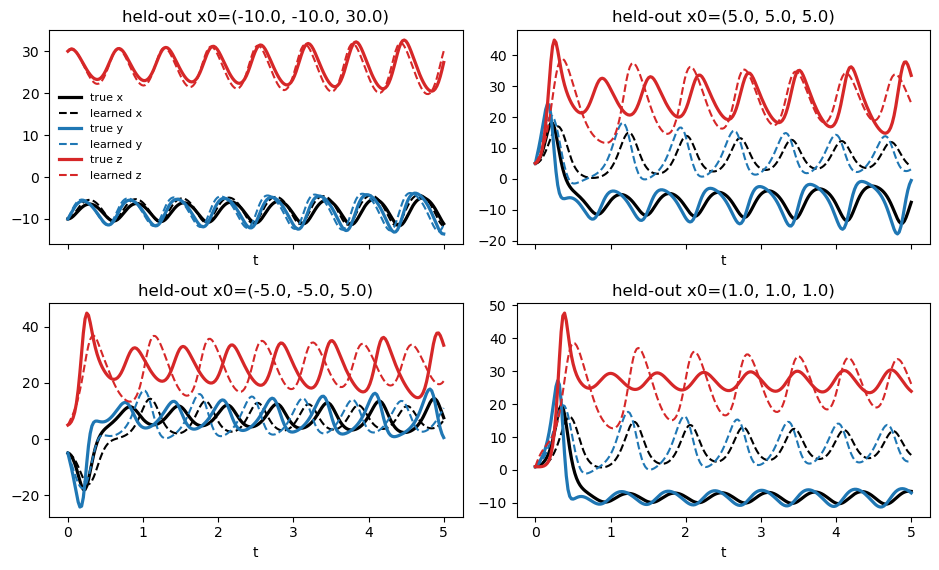

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 5.8), sharex=True)
for ax, i in zip(axes.ravel(), range(x0_eval.shape[0])):
    with torch.no_grad():
        pred = odeint(model_nn, x0_eval[i], t_eval_nn, method="dopri5")

    for j, (name, color) in enumerate(zip(['x','y','z'], ['k','tab:blue','tab:red'])):
        ax.plot(as_list(t_eval_nn), as_list(true_eval[i, :, j]), color=color, lw=2.3,
                label=f"true {name}" if i == 0 else None)
        ax.plot(as_list(t_eval_nn), as_list(pred[:, j]), ls='--', color=color, lw=1.5,
                label=f"learned {name}" if i == 0 else None)

    ax.set_title(f"held-out x0={tuple(x0_eval[i].tolist())}")
    ax.set_xlabel("t")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.savefig("plotWs30.png")
plt.show()

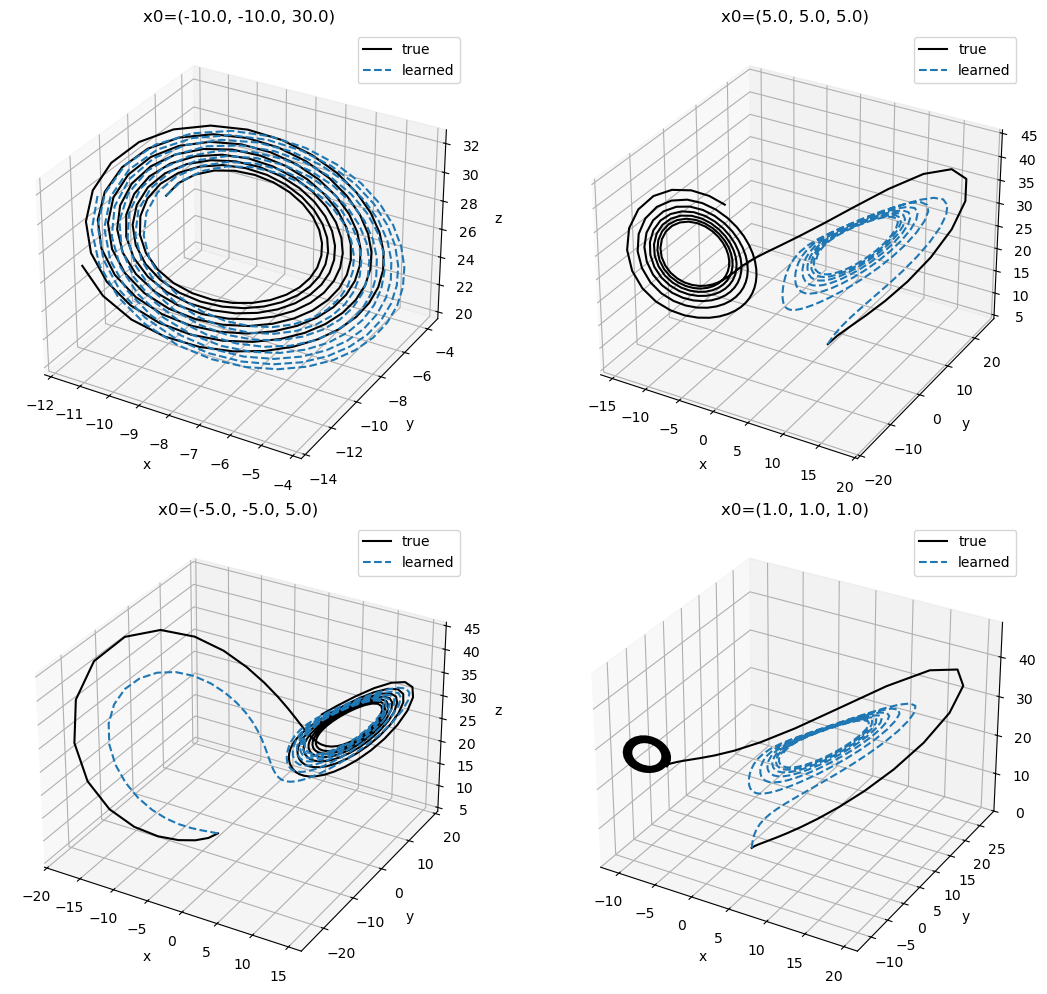

In [27]:
n_traj = x0_eval.shape[0]
fig = plt.figure(figsize=(12, 10))

for i in range(n_traj):
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')

    with torch.no_grad():
        pred = odeint(model_nn, x0_eval[i], t_eval_nn, method="dopri5")

    true_xyz = true_eval[i].cpu().numpy()
    pred_xyz = pred.cpu().numpy()

    ax.plot(true_xyz[:, 0], true_xyz[:, 1], true_xyz[:, 2], color="k", lw=1.5, label="true")
    ax.plot(pred_xyz[:, 0], pred_xyz[:, 1], pred_xyz[:, 2], color="C0", lw=1.5, ls="--", label="learned")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(f"x0={tuple(x0_eval[i].tolist())}")
    ax.legend()

plt.tight_layout()
plt.savefig("3dWS30.png")
plt.show()

## Adding Noise

In [28]:
print("x_mean:", model_nn.x_mean)
print("x_std:", model_nn.x_std)
print("dxdt_std:", model_nn.dxdt_std)
print("Loss am Anfang:", losses[0])
print("Loss am Ende:", losses[-1])

x_mean: tensor([-1.1530, -1.0989, 24.6554])
x_std: tensor([7.9707, 8.8941, 7.4414])
dxdt_std: tensor([39.9586, 56.0258, 68.4228])
Loss am Anfang: [ 1.         94.47910309]
Loss am Ende: [1000.            5.05968428]


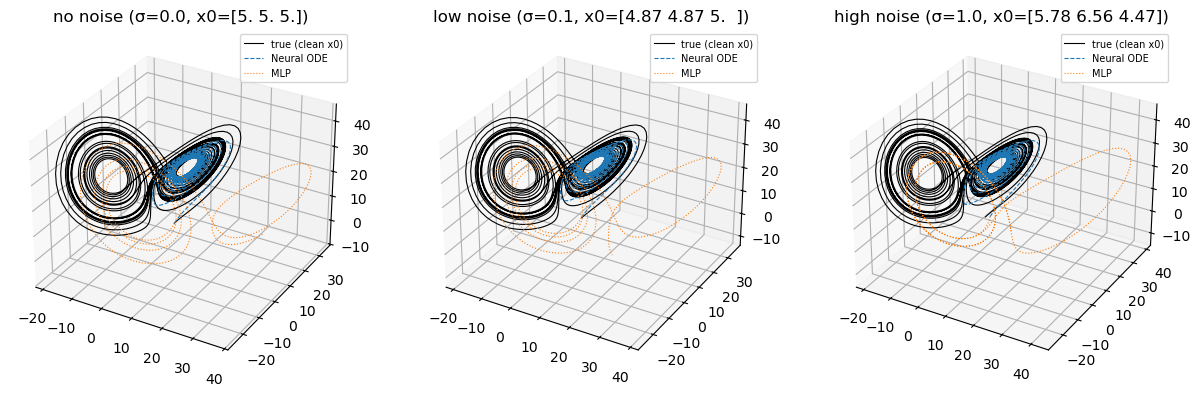

In [29]:
def add_noise(x0, sigma):
    return x0 + sigma * torch.randn_like(x0)

noise_levels = {"no noise": 0.0, "low noise": 0.1, "high noise": 1.0}

x0_clean = torch.tensor([5.0, 5.0, 5.0], device=device, dtype=torch.float32)
t_np = np.linspace(0.0, 30.0, 3000)
t_eval_long = torch.tensor(t_np, device=device, dtype=torch.float32)

# "true" reference trajectory from clean x0 (no noise)
sol = solve_ivp(f, (0, 30), x0_clean.cpu().numpy(), t_eval=t_np, method='RK45')
true_xyz = sol.y.T

fig, axes = plt.subplots(1, len(noise_levels), figsize=(15, 5), subplot_kw={'projection': '3d'})
model_mlp = model_mlp.to(device)


for ax, (name, sigma) in zip(axes, noise_levels.items()):
    x0_noisy = add_noise(x0_clean, sigma)

    with torch.no_grad():
        # Neural ODE rollout
        pred_node = odeint(model_nn, x0_noisy, t_eval_long, method="dopri5").cpu().numpy()

        # MLP rollout (iterative one-step predictions)
        pred_mlp = predict_trajectory(model_mlp, normalize(x0_noisy.cpu().numpy(), data_min, data_max),
                                       n_steps=len(t_eval_mlp)-1, scaler_min=None, scaler_max=None,
                                       data_min=data_min, data_max=data_max)
        pred_mlp = denormalize(pred_mlp, data_min, data_max)

    ax.plot(*true_xyz.T, color="k", lw=0.8, label="true (clean x0)")
    ax.plot(*pred_node.T, color="C0", lw=0.8, ls="--", label="Neural ODE")
    ax.plot(pred_mlp[:, 0], pred_mlp[:, 1], pred_mlp[:, 2], color="C1", lw=0.8, ls=":", label="MLP")
    ax.set_title(f"{name} (σ={sigma}, x0={x0_noisy.cpu().numpy().round(2)})")
    ax.legend(fontsize=7)

#plt.tight_layout()
plt.savefig("noise.png")
plt.show()